# Mean-Variance Portfolio Optimization in Python

This notebook studies how to choose portfolio weights optimally using the principles of mean-variance analysis.

Rather than evaluating a portfolio with fixed weights, the goal here is to determine which allocation of wealth across assets leads to the most attractive portfolio according to a chosen criterion.

## Main objectives

In this notebook, we will:
- simulate many random portfolios
- identify the minimum-variance portfolio
- identify the maximum Sharpe ratio portfolio
- trace the efficient frontier

Portfolio choice is not only about selecting good individual assets.  
It is also about deciding **how much to invest in each asset**.

A portfolio can be improved in different ways :
- minimizing total risk
- maximizing risk-adjusted performance

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Define the investment universe

We select the assets included in the portfolio optimization problem, the benchmark used for comparison, and the time period over which returns will be estimated.

We also specify a risk-free rate, which will later be used to compute Sharpe ratios.

In [2]:
# Risky assets
portfolio_tickers = ["AAPL", "MSFT", "NVDA", "META", "AMZN"]

# Benchmark
benchmark_ticker = "^GSPC"

# Full universe for download
tickers = portfolio_tickers + [benchmark_ticker]

# Sample period
start_date = "2018-01-01"
end_date = "2025-12-31"

# Annual risk-free rate
risk_free_rate = 0.02

print("Portfolio assets:", portfolio_tickers)
print("Benchmark:", benchmark_ticker)
print("Sample period:", start_date, "to", end_date)
print("Risk-free rate:", f"{risk_free_rate:.2%}")

Portfolio assets: ['AAPL', 'MSFT', 'NVDA', 'META', 'AMZN']
Benchmark: ^GSPC
Sample period: 2018-01-01 to 2025-12-31
Risk-free rate: 2.00%


## 2. Download price data and compute returns

We retrieve historical closing prices and transform them into daily simple returns.

These return series will be the raw material for the optimization problem.

In [3]:
prices = yf.download(tickers, start=start_date, end=end_date)["Close"].dropna()

returns = prices.pct_change().dropna()

print(f"Number of observations: {len(returns)}")
print(f"Date range: {returns.index[0].date()} to {returns.index[-1].date()}")

returns.head()

C:\Users\ebens\AppData\Local\Temp\ipykernel_22212\3744141226.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)["Close"].dropna()
[*********************100%***********************]  6 of 6 completed


Number of observations: 2009
Date range: 2018-01-03 to 2025-12-30


Ticker,AAPL,AMZN,META,MSFT,NVDA,^GSPC
Date,,,,,,
2018-01-03,-0.000174,0.012775,0.017914,0.004654,0.065814,0.006399
2018-01-04,0.004645,0.004476,-0.001841,0.008801,0.005271,0.004029
2018-01-05,0.011385,0.016163,0.013671,0.012398,0.008474,0.007034
2018-01-08,-0.003714,0.014425,0.007653,0.001020,0.030641,0.001662
2018-01-09,-0.000115,0.004676,-0.002178,-0.000680,-0.000270,0.001303


## 3. Estimate annualized return and risk inputs
Using daily data, we annualize these quantities with the standard convention of 252 trading days per year:

- annualized expected return = daily mean × 252
- annualized covariance matrix = daily covariance matrix × 252

In [4]:
mean_returns = returns[portfolio_tickers].mean() * 252
cov_matrix = returns[portfolio_tickers].cov() * 252

summary = pd.DataFrame({
    "Annual Return (%)": (mean_returns * 100).round(2),
    "Annual Volatility (%)": (np.sqrt(np.diag(cov_matrix)) * 100).round(2)
})

summary

,Annual Return (%),Annual Volatility (%)
Ticker,,
AAPL,28.73,30.80
MSFT,26.84,28.35
NVDA,58.82,51.30
META,25.10,41.46
AMZN,23.03,34.42


## 4. Define the portfolio formulas

Before optimizing the weights, we need functions that compute the main characteristics of a portfolio for any weight vector \(w\):

- expected portfolio return
- portfolio volatility
- Sharpe ratio

In [5]:
def portfolio_return(weights, mean_returns):
    return np.dot(weights, mean_returns)

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

def portfolio_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    port_return = portfolio_return(weights, mean_returns)
    port_vol = portfolio_volatility(weights, cov_matrix)
    return (port_return - risk_free_rate) / port_vol

## 5. Simulate random portfolios

It is useful to explore the space of feasible portfolios visually.

We generate a large number of random weight vectors satisfying the portfolio budget constraint, compute the corresponding return, volatility, and Sharpe ratio, and then represent the results in risk-return space.

In [7]:
n_portfolios = 5000

results = []
weights_list = []

n_assets = len(portfolio_tickers)

for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights /= weights.sum()

    port_return = portfolio_return(weights, mean_returns)
    port_vol = portfolio_volatility(weights, cov_matrix)
    port_sharpe = portfolio_sharpe(weights, mean_returns, cov_matrix, risk_free_rate)

    results.append([port_return, port_vol, port_sharpe])
    weights_list.append(weights)

results_df = pd.DataFrame(results, columns=["Return", "Volatility", "Sharpe"])

weights_df = pd.DataFrame(weights_list, columns=portfolio_tickers)

simulated_portfolios = pd.concat([results_df, weights_df], axis=1)

simulated_portfolios.head()

,Return,Volatility,Sharpe,AAPL,MSFT,NVDA,META,AMZN
0,0.300849,0.304557,0.922155,0.343606,0.068838,0.117578,0.301971,0.168007
1,0.328287,0.294329,1.047423,0.255757,0.432265,0.181851,0.088285,0.041842
2,0.382477,0.340482,1.064598,0.114175,0.251682,0.368096,0.208755,0.057291
3,0.358775,0.335086,1.011010,0.161941,0.144621,0.299708,0.311967,0.081763
4,0.291365,0.297101,0.913377,0.168315,0.236725,0.105305,0.229565,0.260090


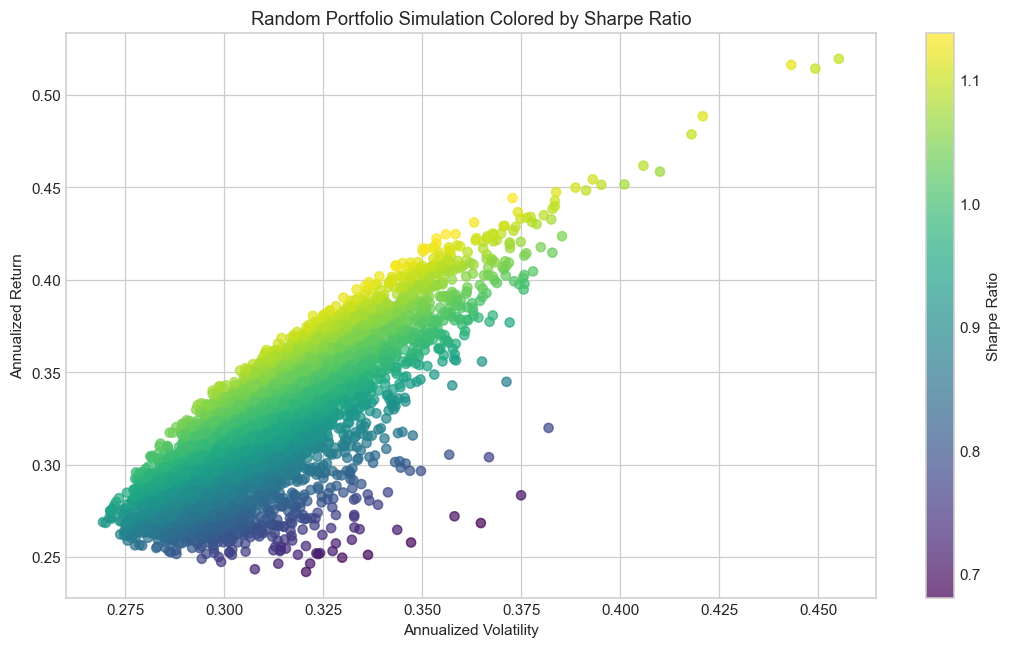

In [9]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    simulated_portfolios["Volatility"],
    simulated_portfolios["Return"],
    c=simulated_portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Random Portfolio Simulation Colored by Sharpe Ratio")
plt.tight_layout()
plt.show()

## 6. Optimize the portfolio weights

We  move to optimization in order to identify precisely:

- the minimum-variance portfolio
- the maximum Sharpe ratio portfolio

We begin with the minimum-variance problem.

#### Minimum-variance portfolio

The first optimization problem consists in finding the portfolio with the lowest possible volatility.

We choose the portfolio weights to minimize portfolio volatility, subject to the usual portfolio constraints:
- the weights sum to 1
- short selling is not allowed

In [ ]:
constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}] #equality extraint
bounds = tuple((0, 1) for _ in range(n_assets))

initial_weights = np.ones(n_assets) / n_assets

print("Initial weights:", initial_weights)

Initial weights: [0.2 0.2 0.2 0.2 0.2]


In [ ]:
min_var_result = minimize(
    portfolio_volatility,
    initial_weights,
    args=(cov_matrix,), #cov_matrix fixed; optimization in respects to weights
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

min_var_weights = min_var_result.x
min_var_return = portfolio_return(min_var_weights, mean_returns)
min_var_volatility = portfolio_volatility(min_var_weights, cov_matrix)
min_var_sharpe = portfolio_sharpe(min_var_weights, mean_returns, cov_matrix, risk_free_rate)

In [13]:
min_var_weights_df = pd.DataFrame({
    "Asset": portfolio_tickers,
    "Weight": min_var_weights
})

min_var_weights_df["Weight"] = min_var_weights_df["Weight"].round(4)
min_var_weights_df

,Asset,Weight
0,AAPL,0.3237
1,MSFT,0.5438
2,NVDA,0.0000
3,META,0.0000
4,AMZN,0.1325


In [14]:
min_var_stats = pd.DataFrame({
    "Metric": ["Annual Return", "Annual Volatility", "Sharpe Ratio"],
    "Value": [min_var_return, min_var_volatility, min_var_sharpe]
})

min_var_stats["Value"] = min_var_stats["Value"].round(4)
min_var_stats

,Metric,Value
0,Annual Return,0.2695
1,Annual Volatility,0.2689
2,Sharpe Ratio,0.9278


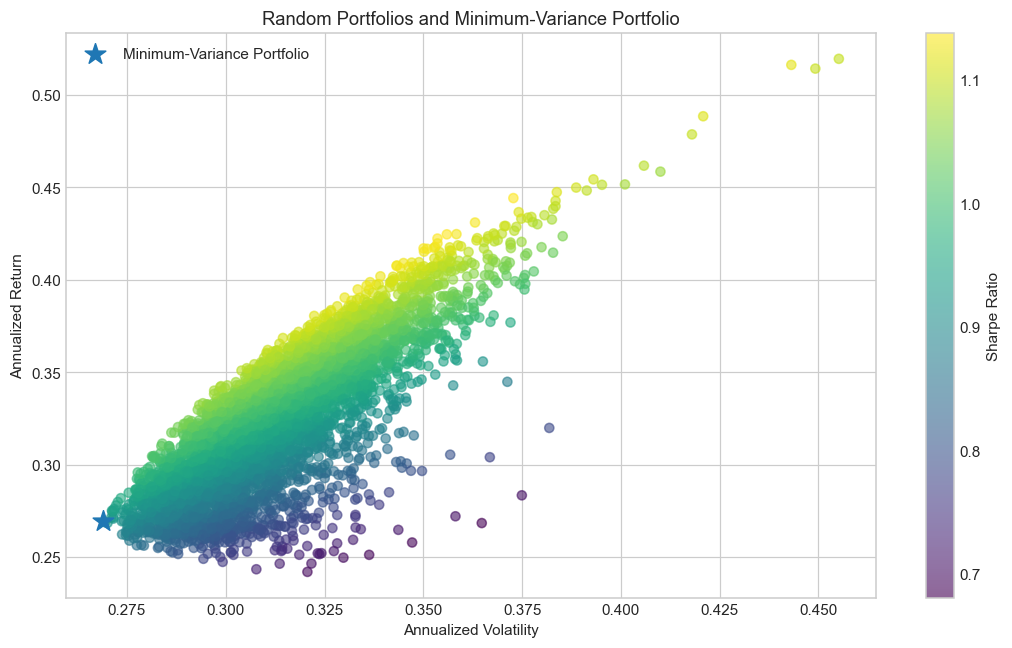

In [16]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    simulated_portfolios["Volatility"],
    simulated_portfolios["Return"],
    c=simulated_portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.scatter(
    min_var_volatility,
    min_var_return,
    marker="*",
    s=200,
    label="Minimum-Variance Portfolio"
)

plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Random Portfolios and Minimum-Variance Portfolio")
plt.legend()
plt.tight_layout()
plt.show()

#### Maximum Sharpe ratio portfolio
Instead of minimizing total risk, we seek the portfolio that maximizes the Sharpe ratio.

This portfolio is often called the **tangency portfolio** in mean-variance theory and is especially useful when a risk-free asset is available.

In [17]:
def negative_portfolio_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    return -portfolio_sharpe(weights, mean_returns, cov_matrix, risk_free_rate)

In [18]:
max_sharpe_result = minimize(
    negative_portfolio_sharpe,
    initial_weights,
    args=(mean_returns, cov_matrix, risk_free_rate),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

max_sharpe_weights = max_sharpe_result.x
max_sharpe_return = portfolio_return(max_sharpe_weights, mean_returns)
max_sharpe_volatility = portfolio_volatility(max_sharpe_weights, cov_matrix)
max_sharpe_ratio = portfolio_sharpe(max_sharpe_weights, mean_returns, cov_matrix, risk_free_rate)

In [19]:
max_sharpe_weights_df = pd.DataFrame({
    "Asset": portfolio_tickers,
    "Weight": max_sharpe_weights
})

max_sharpe_weights_df["Weight"] = max_sharpe_weights_df["Weight"].round(4)
max_sharpe_weights_df

,Asset,Weight
0,AAPL,0.3365
1,MSFT,0.0916
2,NVDA,0.5719
3,META,0.0000
4,AMZN,0.0000


In [20]:
max_sharpe_stats = pd.DataFrame({
    "Metric": ["Annual Return", "Annual Volatility", "Sharpe Ratio"],
    "Value": [max_sharpe_return, max_sharpe_volatility, max_sharpe_ratio]
})

max_sharpe_stats["Value"] = max_sharpe_stats["Value"].round(4)
max_sharpe_stats

,Metric,Value
0,Annual Return,0.4577
1,Annual Volatility,0.3823
2,Sharpe Ratio,1.1449


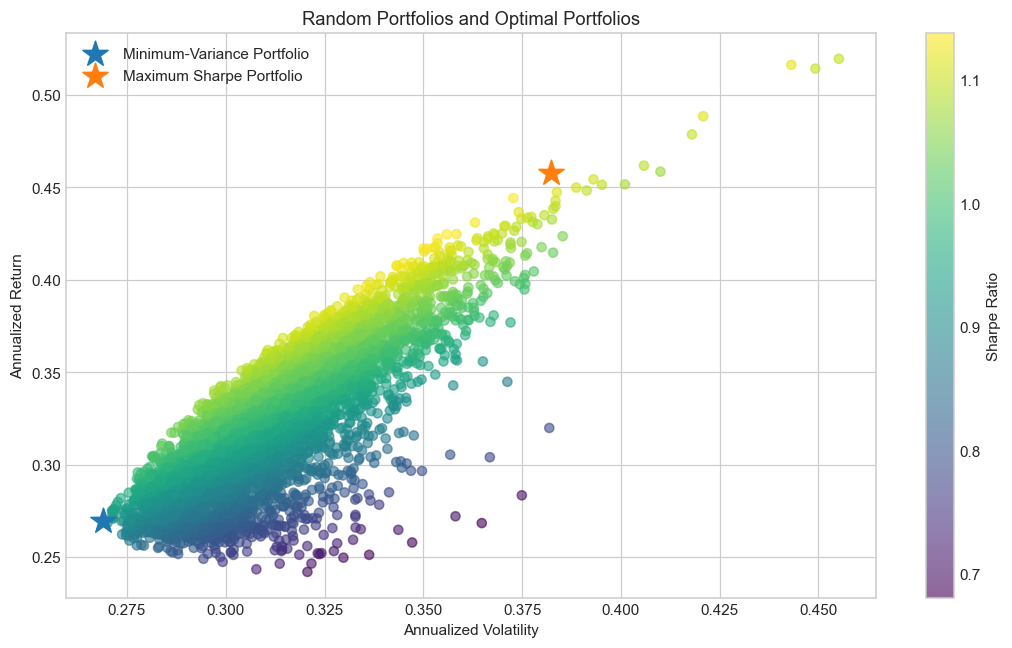

In [21]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    simulated_portfolios["Volatility"],
    simulated_portfolios["Return"],
    c=simulated_portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.scatter(
    min_var_volatility,
    min_var_return,
    marker="*",
    s=300,
    label="Minimum-Variance Portfolio"
)

plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Random Portfolios and Optimal Portfolios")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
comparison_table = pd.DataFrame({
    "Portfolio": ["Minimum Variance", "Maximum Sharpe"],
    "Annual Return": [min_var_return, max_sharpe_return],
    "Annual Volatility": [min_var_volatility, max_sharpe_volatility],
    "Sharpe Ratio": [min_var_sharpe, max_sharpe_ratio]
})

comparison_table = comparison_table.round(4)
comparison_table

,Portfolio,Annual Return,Annual Volatility,Sharpe Ratio
0,Minimum Variance,0.2695,0.2689,0.9278
1,Maximum Sharpe,0.4577,0.3823,1.1449


## 8. Efficient frontier

For each target return, we determine the portfolio with the lowest achievable volatility subject to that return requirement.

The efficient frontier represents the set of portfolios that offer the best possible trade-off between expected return and risk.

### Optimization principle:

For each target return in the grid, we solve a constrained optimization problem:

- minimize portfolio volatility
- subject to the weights summing to 1
- and subject to the portfolio expected return being equal to the chosen target

The result is a sequence of optimal portfolios, one for each target return, from which the efficient frontier can be plotted.

In [24]:
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)

frontier_volatilities = []
frontier_returns = []

for target in target_returns:
    frontier_constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w, target=target: portfolio_return(w, mean_returns) - target}
    ]

    result = minimize(
        portfolio_volatility,
        initial_weights,
        args=(cov_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=frontier_constraints
    )

    if result.success:
        frontier_volatilities.append(result.fun)
        frontier_returns.append(target)

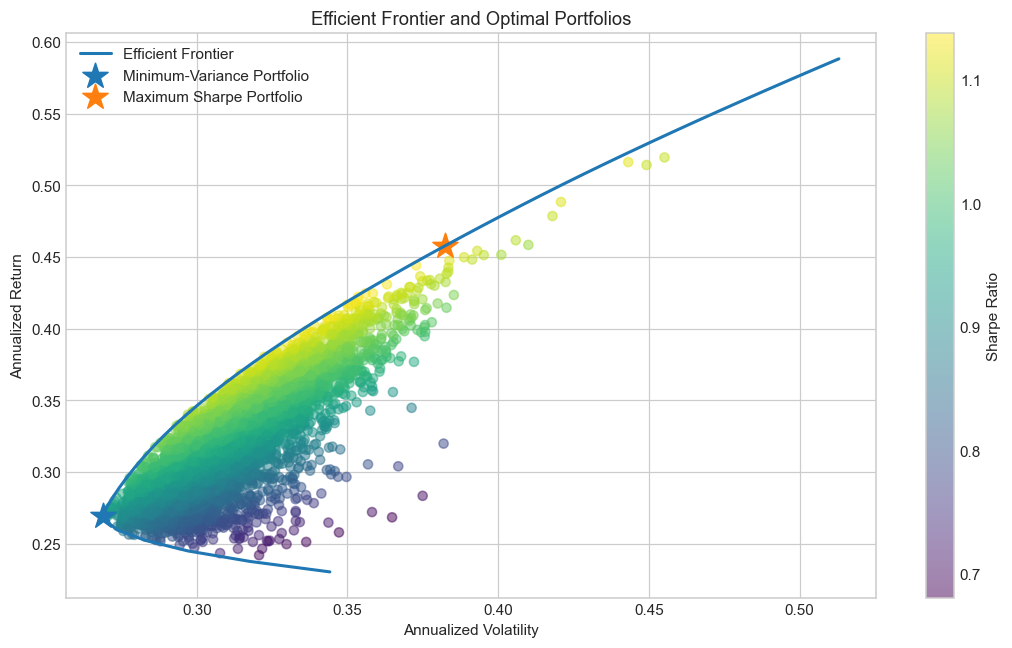

In [25]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    simulated_portfolios["Volatility"],
    simulated_portfolios["Return"],
    c=simulated_portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.5
)

plt.plot(
    frontier_volatilities,
    frontier_returns,
    linewidth=2,
    label="Efficient Frontier"
)

plt.scatter(
    min_var_volatility,
    min_var_return,
    marker="*",
    s=300,
    label="Minimum-Variance Portfolio"
)

plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Efficient Frontier and Optimal Portfolios")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The efficient frontier forms the upper boundary of the feasible portfolio set.

Any portfolio located below this frontier is inefficient, because another feasible portfolio exists with the same level of risk and a higher expected return, or equivalently with the same expected return and a lower level of risk.

The minimum-variance portfolio appears at the leftmost point of the frontier.  
The maximum Sharpe ratio portfolio lies on the efficient frontier as well and corresponds to the portfolio with the best excess return-to-risk ratio.

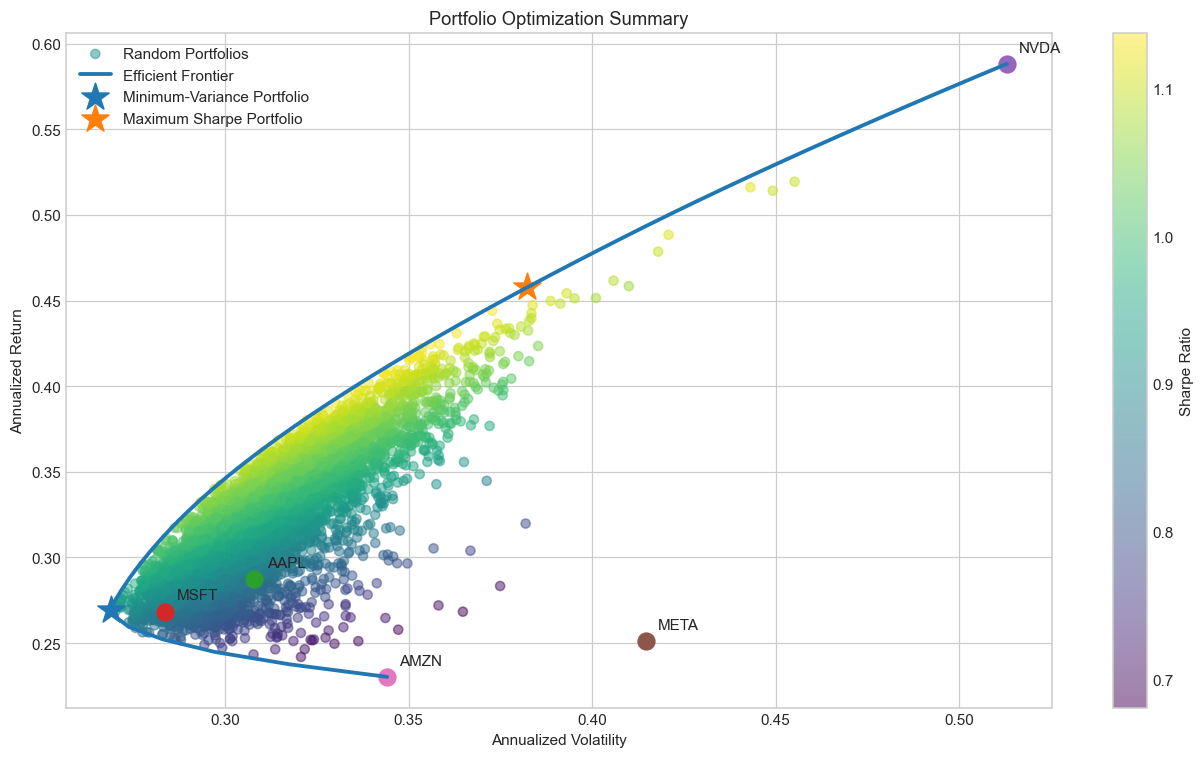

In [26]:
plt.figure(figsize=(12, 7))

# Random portfolios
scatter = plt.scatter(
    simulated_portfolios["Volatility"],
    simulated_portfolios["Return"],
    c=simulated_portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    label="Random Portfolios"
)

# Efficient frontier
plt.plot(
    frontier_volatilities,
    frontier_returns,
    linewidth=2.5,
    label="Efficient Frontier"
)

# Minimum-variance portfolio
plt.scatter(
    min_var_volatility,
    min_var_return,
    marker="*",
    s=350,
    label="Minimum-Variance Portfolio"
)

# Maximum Sharpe portfolio
plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=350,
    label="Maximum Sharpe Portfolio"
)

# Individual stocks
for ticker in portfolio_tickers:
    stock_return = mean_returns[ticker]
    stock_volatility = np.sqrt(cov_matrix.loc[ticker, ticker])

    plt.scatter(
        stock_volatility,
        stock_return,
        s=120
    )

    plt.annotate(
        ticker,
        (stock_volatility, stock_return),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10
    )

# Colorbar and labels
plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Portfolio Optimization Summary")
plt.legend()
plt.tight_layout()
plt.show()